# Resumen para examen: Seaborn paso a paso

Este cuaderno resume los ejercicios del archivo que subiste y los convierte en una guía de estudio rápida, clara y práctica.

## Cómo usar este notebook
- Lee primero el bloque **Qué hace**.
- Después repasa el bloque **Paso a paso**.
- Luego mira el **código limpio**.
- Antes del examen, quédate con:
  - qué parámetro hace qué,
  - cuándo usar `hue`, `size`, `style`, `kde`, `ci`, `annot`,
  - y la diferencia entre **Matplotlib** y **Seaborn**.

## Idea general que más cae en examen
**Matplotlib** suele ser más manual.  
**Seaborn** suele ser más directo, más estético y entiende mejor los datos en `DataFrame`.

## Chuleta rápida de parámetros
- `data=`: DataFrame completo
- `x=`, `y=`: columnas o variables a representar
- `hue=`: separa por color según una categoría
- `style=`: cambia estilo de línea o marcador por categoría
- `size=`: cambia tamaño de los puntos según una variable
- `palette=`: paleta de colores
- `ax=`: dibuja dentro de un eje concreto de Matplotlib
- `kde=True`: añade curva suavizada en histogramas
- `ci=`: intervalo de confianza
- `annot=True`: escribe valores dentro de un heatmap

## Consejo express para el examen
Si te piden **“explica por qué Seaborn es más cómodo”**, responde algo parecido a esto:

> Porque trabaja muy bien con DataFrames, añade estética por defecto, interpreta categorías automáticamente y en varios gráficos incorpora cálculos estadísticos sin tener que hacerlos a mano.


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set_theme()


## 1) Nube de puntos por grupos: Matplotlib vs Seaborn

### Qué hace
Representa una nube de puntos donde cada grupo aparece con un color distinto.

### Qué quieren que entiendas
- En **Matplotlib** normalmente tienes que separar los grupos manualmente.
- En **Seaborn** basta indicar la columna categórica con `hue`.

### Paso a paso
1. Se crea un `DataFrame` con precio, ventas y categoría.
2. En Matplotlib:
   - se crea la figura,
   - se recorre cada categoría con un bucle,
   - se filtran los datos,
   - se pinta cada subconjunto con `scatter`.
3. En Seaborn:
   - se pasa todo el `DataFrame`,
   - `hue='categoria'` hace el trabajo de separar por colores automáticamente.

### Lo importante para memorizar
- `sns.scatterplot(..., hue='categoria')` evita filtrar a mano.
- Seaborn también genera la leyenda de forma automática.

### Tip de examen
Si te preguntan **cuándo usar `hue`**, di:
> Cuando una variable categórica debe diferenciarse visualmente por colores.

### Errores típicos
- Escribir mal el nombre de la columna en `hue`.
- Pasar `x` e `y` sin indicar `data` cuando estás trabajando con columnas de un DataFrame.


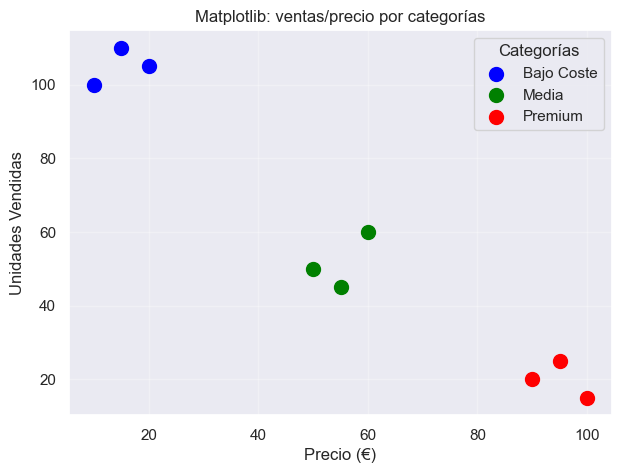

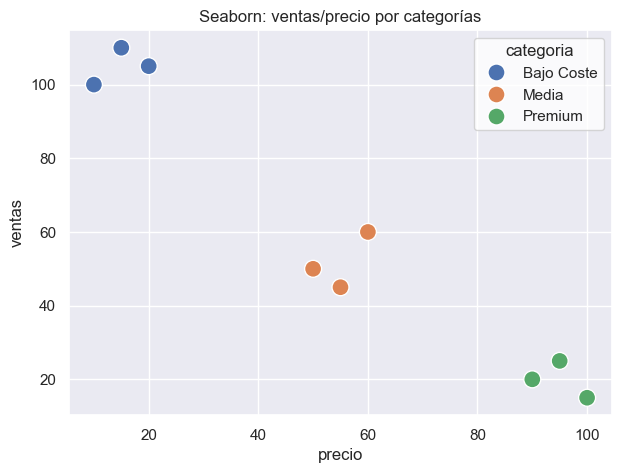

In [2]:
# Datos de ejemplo
df = pd.DataFrame({
    'precio': [10, 15, 20, 50, 55, 60, 90, 95, 100],
    'ventas': [100, 110, 105, 50, 45, 60, 20, 25, 15],
    'categoria': ['Bajo Coste', 'Bajo Coste', 'Bajo Coste',
                  'Media', 'Media', 'Media',
                  'Premium', 'Premium', 'Premium']
})

# Matplotlib: hay que separar grupos a mano
fig, ax = plt.subplots(figsize=(7, 5))
for cat, color in zip(['Bajo Coste', 'Media', 'Premium'], ['blue', 'green', 'red']):
    filtro = df[df['categoria'] == cat]
    ax.scatter(filtro['precio'], filtro['ventas'], c=color, label=cat, s=100)

ax.set_title('Matplotlib: ventas/precio por categorías')
ax.set_xlabel('Precio (€)')
ax.set_ylabel('Unidades Vendidas')
ax.legend(title="Categorías")
ax.grid(True, alpha=0.3)
plt.show()

# Seaborn: interpreta la categoría con hue
fig, ax = plt.subplots(figsize=(7, 5))
sns.set_theme(style="whitegrid")
sns.scatterplot(data=df, x='precio', y='ventas', hue='categoria', s=150, ax=ax)
ax.set_title('Seaborn: ventas/precio por categorías')
plt.show()


## 2) Regresión: Matplotlib manual vs `regplot`

### Qué hace
Dibuja puntos, una recta de regresión y una zona de confianza.

### Qué quieren que entiendas
- Con Matplotlib hay que calcular la regresión y el error manualmente.
- Con Seaborn, `regplot` lo hace casi todo solo.

### Paso a paso en Matplotlib
1. Se definen `x` e `y`.
2. `np.polyfit(x, y, 1)` calcula pendiente `m` e intercepto `b`.
3. Se obtiene la predicción: `y_pred = m*x + b`.
4. Se estima un error.
5. Se pintan:
   - los puntos,
   - la recta,
   - la banda sombreada con `fill_between`.

### Paso a paso en Seaborn
1. Se llama a `sns.regplot`.
2. `ci=95` pide intervalo de confianza al 95%.
3. `scatter_kws` personaliza puntos.
4. `line_kws` personaliza la recta.

### Lo importante para memorizar
- `regplot` = dispersión + ajuste lineal + confianza.
- `ci` controla el intervalo de confianza.
- Seaborn incorpora parte estadística sin que tengas que programarla.

### Tip de examen
Si te preguntan la diferencia entre `scatterplot` y `regplot`:
- `scatterplot`: solo puntos.
- `regplot`: puntos + regresión + zona de confianza.


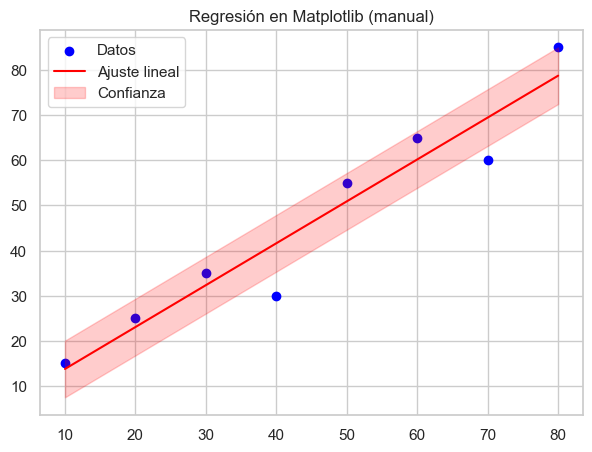

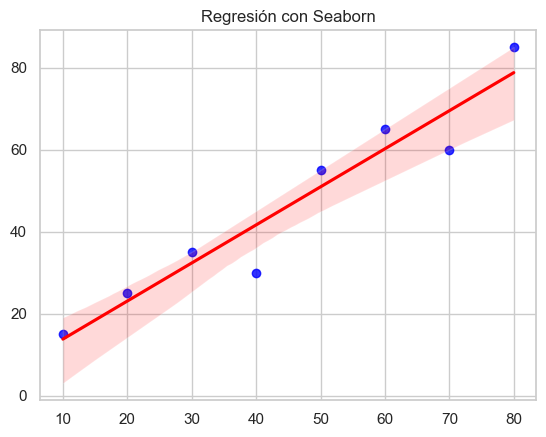

In [3]:
x = np.array([10, 20, 30, 40, 50, 60, 70, 80])
y = np.array([15, 25, 35, 30, 55, 65, 60, 85])

# Matplotlib: cálculo manual
m, b = np.polyfit(x, y, 1)
y_pred = m * x + b
error = np.std(y - y_pred)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x, y, color='blue', label='Datos')
ax.plot(x, y_pred, color='red', label='Ajuste lineal')
ax.fill_between(x, y_pred - error, y_pred + error, color='red', alpha=0.2, label='Confianza')
ax.set_title("Regresión en Matplotlib (manual)")
ax.legend()
plt.show()

# Seaborn: todo resumido
sns.regplot(x=x, y=y, ci=95, scatter_kws={'color': 'blue'}, line_kws={'color': 'red'})
plt.title("Regresión con Seaborn")
plt.show()


## 3) Gráficas de Seaborn dentro de una figura de Matplotlib

### Qué hace
Muestra cómo usar Seaborn en subgráficos creados con Matplotlib.

### Idea clave
Matplotlib crea la **estructura** de la figura y Seaborn rellena cada eje.

### Paso a paso
1. Se crea un `DataFrame`.
2. `plt.subplots(1, 2)` crea una figura con dos ejes.
3. En el primer `ax` se pinta un histograma.
4. En el segundo `ax` se pinta una nube de puntos.
5. `tight_layout()` ajusta espacios.

### Qué debes saber decir
- `ax=` le dice a Seaborn **dónde** dibujar.
- Esto se usa mucho para dashboards, comparativas y composiciones.

### Tip de examen
Si aparece una pregunta tipo:
> “¿Se puede usar Seaborn dentro de una figura de Matplotlib?”
La respuesta es:
> Sí, pasando el eje con `ax=`.


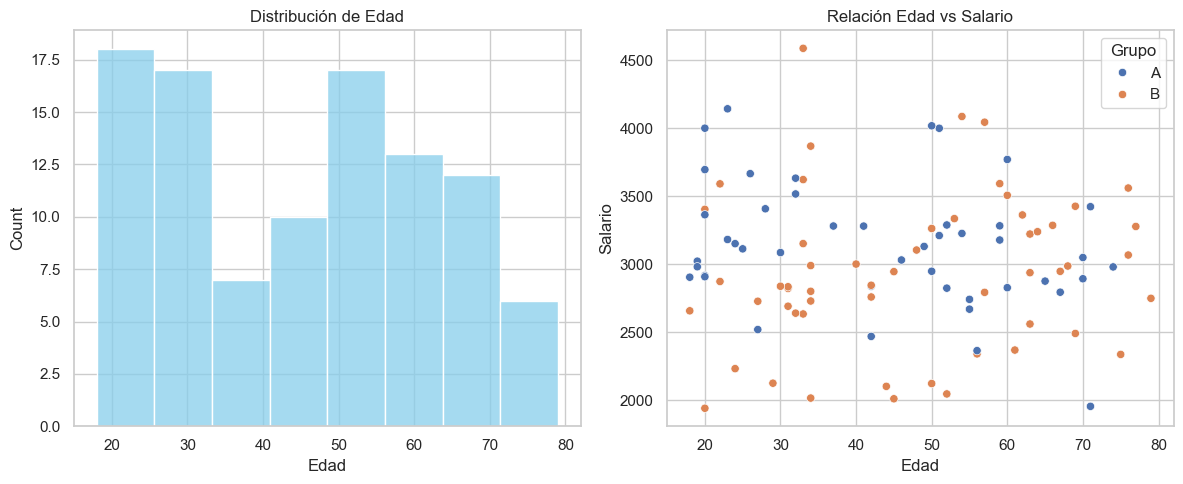

In [4]:
data = pd.DataFrame({
    'Edad': np.random.randint(18, 80, 100),
    'Salario': np.random.normal(3000, 500, 100),
    'Grupo': np.random.choice(['A', 'B'], 100)
})

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=data, x='Edad', ax=ax[0], color='skyblue')
ax[0].set_title('Distribución de Edad')

sns.scatterplot(data=data, x='Edad', y='Salario', hue='Grupo', ax=ax[1])
ax[1].set_title('Relación Edad vs Salario')

plt.tight_layout()
plt.show()


## 4) Nube de puntos y gráfico de burbujas

### Qué hace
Representa dos variables en los ejes y usa el tamaño del punto para meter una tercera variable.

### Idea clave
Un gráfico de burbujas es básicamente un `scatter` donde el tamaño también comunica información.

### Paso a paso
1. Se crea un `DataFrame` con presupuesto, ventas y clientes.
2. `x='Presupuesto'` y `y='Ventas'`.
3. `hue='Clientes'` cambia el color según número de clientes.
4. `size='Clientes'` cambia el tamaño según número de clientes.
5. `sizes=(20, 500)` fija el rango visual de tamaños.

### Qué memorizar
- `hue` = color
- `size` = tamaño
- `palette` = conjunto de colores

### Tip de examen
Si te preguntan:
> “¿Cómo represento una tercera variable?”
Responde:
> Con `hue` o con `size`; y si quiero más información visual, con ambos.


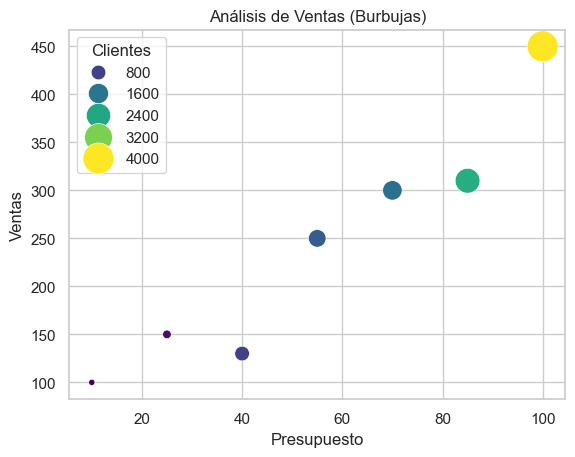

In [5]:
df_burbujas = pd.DataFrame({
    'Presupuesto': [10, 25, 40, 55, 70, 85, 100],
    'Ventas': [100, 150, 130, 250, 300, 310, 450],
    'Clientes': [50, 200, 800, 1200, 1500, 2500, 4000]
})

sns.scatterplot(
    data=df_burbujas,
    x='Presupuesto',
    y='Ventas',
    hue='Clientes',
    size='Clientes',
    sizes=(20, 500),
    palette='viridis'
)

plt.title('Análisis de Ventas (Burbujas)')
plt.show()


## 5) Gráfico de líneas múltiples

### Qué hace
Muestra varias líneas en la misma gráfica: una por jugador.

### Idea clave
Seaborn interpreta el DataFrame en formato largo y crea una línea por categoría.

### Paso a paso
1. Se construye un `DataFrame` con:
   - partido,
   - kilómetros recorridos,
   - jugador.
2. `x='Partido'` marca la secuencia.
3. `y='KM'` es la variable numérica.
4. `hue='Jugador'` separa cada jugador en un color distinto.
5. `style='Jugador'` cambia el estilo de línea.
6. `markers=True` añade marcadores en cada punto.

### Qué memorizar
- `lineplot` funciona muy bien con datos “largos”.
- `hue` y `style` ayudan a diferenciar líneas.

### Error típico
Tener los datos en formato ancho y no entender por qué no sale una línea por grupo.


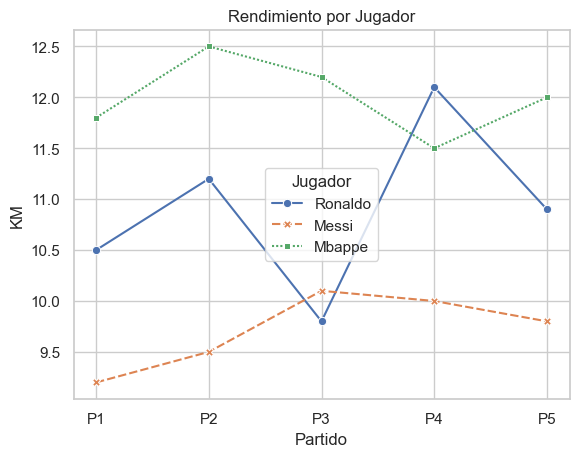

In [6]:
df_lineas = pd.DataFrame({
    'Partido': ['P1', 'P2', 'P3', 'P4', 'P5'] * 3,
    'KM': [10.5, 11.2, 9.8, 12.1, 10.9,
           9.2, 9.5, 10.1, 10.0, 9.8,
           11.8, 12.5, 12.2, 11.5, 12.0],
    'Jugador': ['Ronaldo'] * 5 + ['Messi'] * 5 + ['Mbappe'] * 5
})

sns.lineplot(data=df_lineas, x='Partido', y='KM',
             hue='Jugador', style='Jugador', markers=True)

plt.title('Rendimiento por Jugador')
plt.show()


## 6) Histograma con KDE

### Qué hace
Muestra la distribución de una variable numérica.

### Idea clave
Seaborn puede dibujar:
- barras del histograma,
- y además una curva suave de densidad (`kde=True`).

### Paso a paso
1. Se generan edades aleatorias.
2. `bins=10` divide los datos en 10 intervalos.
3. `kde=True` añade la curva de densidad.
4. `alpha=0.5` da transparencia.
5. `element='bars'` define el estilo visual.

### Qué significa KDE
Es una curva suavizada que ayuda a ver la forma general de la distribución.

### Tip de examen
Si te preguntan:
> “¿Qué diferencia hay entre histograma y KDE?”
Puedes decir:
> El histograma agrupa frecuencias por intervalos; KDE es una estimación suavizada de la distribución.


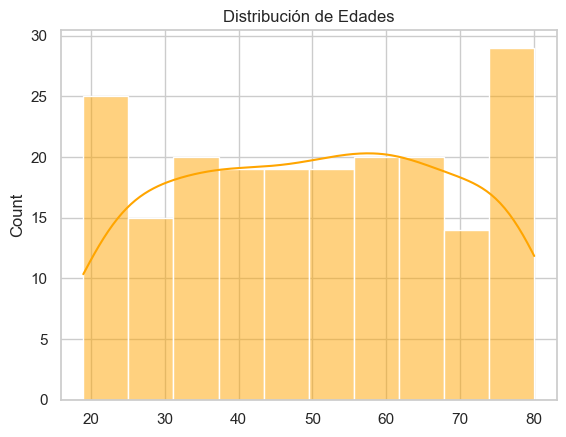

In [7]:
edades = np.random.randint(18, 81, size=200)

sns.histplot(edades, bins=10, kde=True,
             color='orange', alpha=0.5, element='bars')

plt.title('Distribución de Edades')
plt.show()


## 7) Barras con `barplot`

### Qué hace
Representa categorías con barras.

### Idea clave
En Seaborn, `barplot` suele resumir estadísticamente los datos.  
Si hay varias observaciones por categoría, por defecto suele mostrar una estimación central y barras de incertidumbre.

### Ojo con este ejemplo
El ejemplo original es muy simple, pero para estudiar conviene recordar el caso más típico: **categoría + valor**.

### Paso a paso
1. Se indican categorías.
2. Se indican valores.
3. Se elige una paleta.
4. Se dibuja el gráfico.

### Qué memorizar
- Para datos resumidos simples, puedes pasar listas.
- Para análisis más serios, mejor usar `data=...`, `x=...`, `y=...`.

### Tip de examen
Si comparan `barplot` con `countplot`:
- `barplot`: representa un valor agregado por categoría.
- `countplot`: cuenta cuántas veces aparece cada categoría.


C:\Users\usuario\AppData\Local\Temp\ipykernel_21196\3444806450.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=categorias, y=valores, palette='magma')


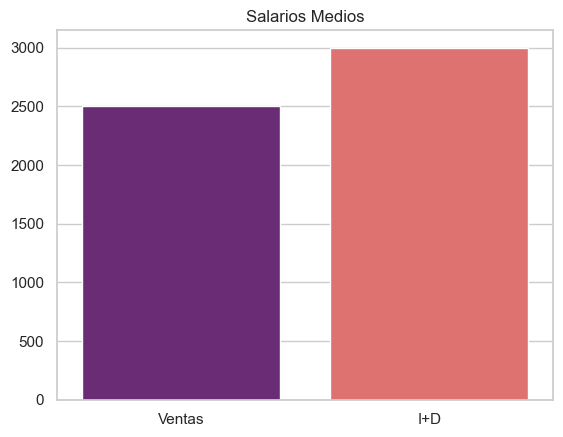

In [8]:
categorias = ['Ventas', 'I+D']
valores = [2500, 3000]

sns.barplot(x=categorias, y=valores, palette='magma')
plt.title('Salarios Medios')
plt.show()


## 8) Boxplot y violinplot

### Qué hacen
Ambos comparan distribuciones por categorías.

### Diferencia clave
- **Boxplot**: resume con mediana, cuartiles y outliers.
- **Violinplot**: además enseña la forma de la distribución.

### Paso a paso
1. Se generan datos sintéticos para dos departamentos.
2. Se juntan en arrays y/o en un DataFrame.
3. Se dibuja:
   - un `boxplot`,
   - un `violinplot`.
4. Se compara qué información da cada uno.

### Qué memorizar del boxplot
- línea central: mediana,
- caja: rango intercuartílico,
- puntos externos: posibles outliers.

### Qué memorizar del violinplot
- ancho del violín = mayor o menor densidad de datos.

### Tip de examen
Si te preguntan cuál usar:
- usa **boxplot** para resumen rápido,
- usa **violinplot** para ver la forma completa de la distribución.


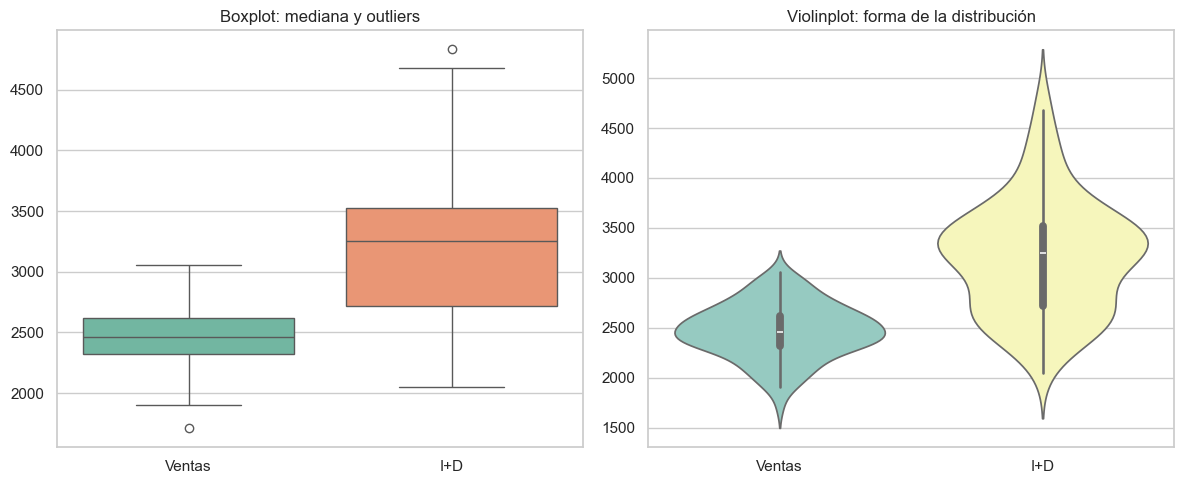

In [9]:
np.random.seed(42)
datos_dep_A = np.random.normal(2500, 300, 100)
datos_dep_B = np.random.normal(3200, 600, 100)

df_salarios = pd.DataFrame({
    'Sueldo': np.concatenate([datos_dep_A, datos_dep_B]),
    'Departamento': ['Ventas'] * 100 + ['I+D'] * 100
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

categorias = ['Ventas'] * 100 + ['I+D'] * 100
valores = np.concatenate([datos_dep_A, datos_dep_B])

sns.boxplot(x=categorias, y=valores, ax=ax1, palette='Set2', hue=categorias, legend=False)
ax1.set_title('Boxplot: mediana y outliers')

sns.violinplot(x=categorias, y=valores, ax=ax2, palette='Set3', hue=categorias, legend=False)
ax2.set_title('Violinplot: forma de la distribución')

plt.tight_layout()
plt.show()


## 9) Violinplot con cuartiles internos

### Qué hace
Muestra la distribución y, además, marca los cuartiles dentro del violín.

### Paso a paso
1. Se usa el `DataFrame` de salarios.
2. `x='Departamento'`, `y='Sueldo'`.
3. `inner='quartile'` dibuja percentiles 25, 50 y 75.

### Qué memorizar
`inner='quartile'` es una palabra clave muy útil para examen.

### Tip de examen
Si piden “mediana y cuartiles dentro del violín”, la respuesta es:
```python
inner='quartile'
```


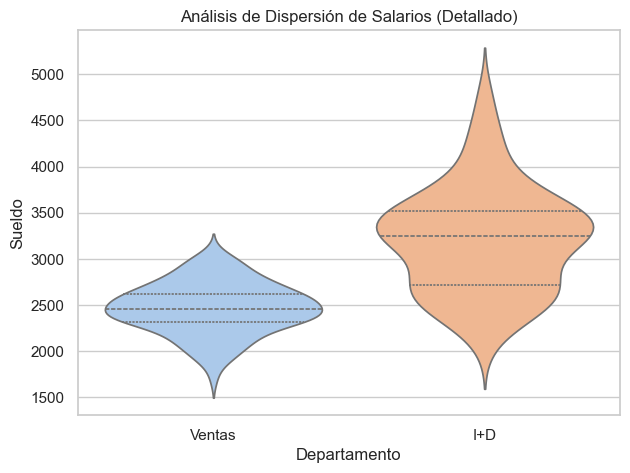

In [10]:
plt.figure(figsize=(7, 5))

sns.violinplot(
    data=df_salarios,
    x='Departamento',
    y='Sueldo',
    palette='pastel',
    inner='quartile',
    hue='Departamento',
    legend=False
)

plt.title('Análisis de Dispersión de Salarios (Detallado)')
plt.show()


## 10) Heatmap o mapa de calor

### Qué hace
Representa una matriz usando colores.

### Idea clave
Cada celda cambia de color según el valor que tenga.

### Paso a paso
1. Se crea una matriz numérica.
2. `sns.heatmap(matriz, ...)` la pinta.
3. `cmap='YlGnBu'` elige la paleta.
4. Si activas `annot=True`, aparecen números en las celdas.

### Qué memorizar
- `annot=True` escribe valores.
- `cmap=` cambia colores.
- Muy útil para correlaciones o tablas numéricas.

### Tip de examen
Si te preguntan para qué sirve:
> Para visualizar rápidamente patrones, intensidades o relaciones dentro de matrices.


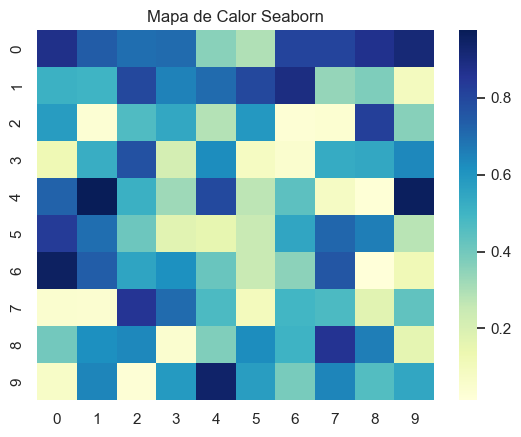

In [11]:
matriz = np.random.rand(10, 10)

sns.heatmap(matriz, annot=False, cmap='YlGnBu')
plt.title('Mapa de Calor Seaborn')
plt.show()


## 11) Nube de puntos con recta de regresión usando `lmplot`

### Qué hace
Crea una nube de puntos, recta de tendencia y separación por grupos.

### Idea clave
`lmplot` está muy orientado a análisis relacional y regresión.

### Paso a paso
1. Se carga el dataset `tips`.
2. `x='total_bill'` y `y='tip'`.
3. `hue='smoker'` separa fumadores y no fumadores.
4. Se dibuja una recta por grupo.

### Diferencia rápida entre `regplot` y `lmplot`
- `regplot`: más simple, trabaja bien en un eje concreto.
- `lmplot`: más orientado a figuras de alto nivel y relaciones por grupos.

### Tip de examen
Si ves una pregunta de:
> “relación entre dos variables numéricas con tendencia por categorías”
piensa en `lmplot` o `regplot`.


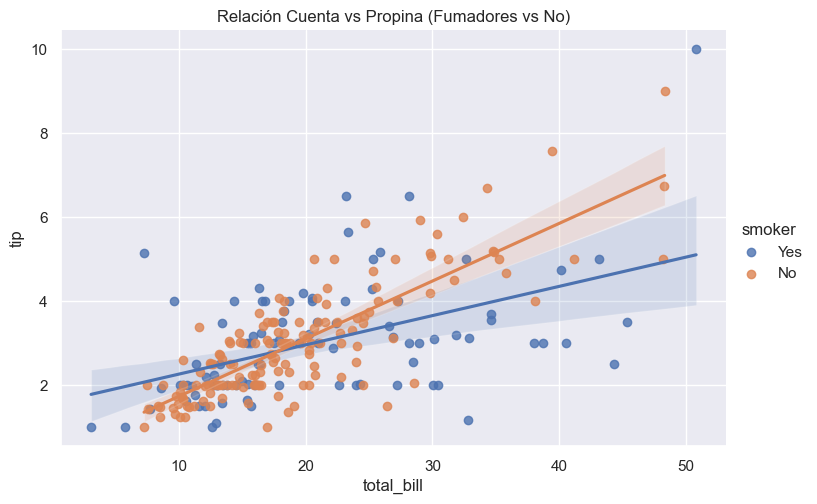

In [12]:
tips = sns.load_dataset("tips")

sns.set_theme(style="darkgrid")
sns.lmplot(data=tips, x="total_bill", y="tip", hue="smoker", aspect=1.5)

plt.title("Relación Cuenta vs Propina (Fumadores vs No)")
plt.show()


## 12) Bonus: Plotly

### Por qué aparece aquí
No es Seaborn, pero en el material sale como comparación.

### Idea clave
Plotly permite gráficos interactivos:
- zoom,
- hover,
- movimiento,
- más interacción en notebooks.

### Qué hace este ejemplo
Usa un diagrama de dispersión con burbujas donde:
- `x` es PIB per cápita,
- `y` es esperanza de vida,
- `size` es población,
- `color` es continente.

### Tip de examen
Si comparan Seaborn y Plotly:
- **Seaborn**: rápido, bonito, estadístico, ideal para análisis estático.
- **Plotly**: interactivo, ideal para exploración y presentaciones.


In [13]:
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "notebook"

df_plotly = px.data.gapminder().query("year == 2007")

fig = px.scatter(
    df_plotly,
    x="gdpPercap",
    y="lifeExp",
    size="pop",
    color="continent",
    hover_name="country",
    log_x=True,
    size_max=60,
    title="PIB vs Esperanza de Vida (2007)"
)

fig.show()


ModuleNotFoundError: No module named 'plotly'

# Preguntas cortas que podrían caer

## 1. ¿Para qué sirve `hue`?
Para separar visualmente los datos por categorías usando colores.

## 2. ¿Para qué sirve `size`?
Para representar una variable adicional mediante el tamaño.

## 3. ¿Para qué sirve `style`?
Para cambiar el tipo de línea o marcador según una categoría.

## 4. ¿Qué hace `kde=True`?
Añade una curva suavizada de densidad en histogramas.

## 5. ¿Qué hace `annot=True` en heatmap?
Escribe el valor numérico dentro de cada celda.

## 6. ¿Qué hace `ci=95`?
Pide un intervalo de confianza del 95%.

## 7. ¿Qué diferencia hay entre boxplot y violinplot?
El boxplot resume; el violinplot además enseña la forma de la distribución.

## 8. ¿Qué ventaja tiene Seaborn frente a Matplotlib?
Menos código manual, mejor estética por defecto y mejor integración con DataFrames.


# Estrategia final de repaso antes del examen

## En 10 minutos
Repasa solo esto:
1. `scatterplot`
2. `lineplot`
3. `histplot`
4. `barplot`
5. `boxplot` y `violinplot`
6. `heatmap`
7. `regplot` / `lmplot`

## En 5 minutos
Quédate con estas asociaciones:
- categorías → `hue`
- tamaño → `size`
- líneas múltiples → `lineplot`
- distribución → `histplot`
- resumen estadístico → `boxplot`
- distribución detallada → `violinplot`
- matriz → `heatmap`
- relación con tendencia → `regplot` / `lmplot`

## Frase-resumen para memorizar
> Seaborn simplifica la visualización estadística porque entiende bien los DataFrames, automatiza estilos y reduce mucho el código respecto a Matplotlib.
